[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ichristov/intermediate-fluid-mechanics/blob/main/dimensional_analysis.ipynb)


# LEARNING OBJECTIVE

After exploring this notebook, you will be able to "automate" dimensional analysis using concepts from linear algebra. Then, Buckingham's $\Pi$ theorem is just the rank&ndash;nullity theorem!

# PRELIMINARIES

[run the next cell to setup Python environment customizations and load packages]

In [1]:
# sympy setup
from sympy.vector import *
import sympy as sp
sp.init_printing()

## Credit

Initial version written by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University.

# THE DIMENSIONAL MATRIX

The columns of the dimensional matrix represent the powers of the primary dimensions needed to "get the units" of any given parameter in a dimensional analysis problem.

For example, for pressure-driven flow in a slot with a moving wall, the dimensional matrix is
$$
\begin{array}{c|c|c|c|c|c|c}
& \hat{Q} & L & h & \Delta p & V_0 & \mu_0 \\
\hline
\mathsf{M} & 0 & 0 & 0 & 1 & 0 & 1\\
\hline
\mathsf{L} & 2 & 1 & 1 & -1 & 1 & -1\\
\hline
\mathsf{T} & -1 & 0 & 0 & -2 & -1 & -1
\end{array}
$$
where $\hat{Q}$ is the flow rate per _unit width_ (area flow rate).

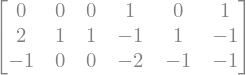

In [2]:
DimMat = sp.Matrix(
    [[0, 0, 0, 1, 0, 1], [2, 1, 1, -1, 1, -1], [-1, 0, 0, -2, -1, -1]])
DimMat

To get the units of, say $V_0$, the fifth parameter in our listing (and this order matters, we have to set it once and follow it for the remainder of the problem), we simply right-multiply the matrix by the _unit_ column vector $[0,0,0,0,1,0]^\top$ as:

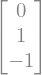

In [3]:
# transpose .T to ensure it's a column vector
V0 = sp.Matrix([[0, 0, 0, 0, 1, 0]]).T
V0dims = DimMat*V0
V0dims

The three elements of this resulting vector are the powers of $\mathsf{M}$, $\mathsf{L}$ and $\mathsf{T}$ that give the dimensions of $V_0$, that is
$$[V_0] = \mathsf{M}^{\color{firebrick}{0}}\mathsf{L}^{\color{firebrick}{1}}\mathsf{T}^{\color{firebrick}{-1}}.$$

Now, by this logic, we could also generate the dimensions of any _multiplicative_ combination of variables (from the simple fact that multiplication means the powers in the dimensions add up), as linear combinations of the unit vectors.

Consider $V_0^2h/L = \hat{Q}^{\color{firebrick}{0}}L^{\color{firebrick}{-1}}h^{\color{firebrick}{1}}\Delta p^{\color{firebrick}{0}}V_0^{\color{firebrick}{2}}\mu_0^{\color{firebrick}{0}}$. The vector representing this new variable is `[0,0,1,0,0,0].T - [0,1,0,0,0,0].T + 2*[0,0,0,0,1,0].T`, and we right-multiply it into `DimMat` to get:

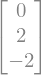

In [4]:
NewVar = sp.Matrix([[0, 0, 1, 0, 0, 0]]).T \
         - sp.Matrix([[0, 1, 0, 0, 0, 0]]).T \
         + 2*sp.Matrix([[0, 0, 0, 0, 1, 0]]).T
NewVardims = DimMat*NewVar
NewVardims

Indeed the dimensions of $V_0^2h/L$ are velocity squared, or $\mathsf{M}^0\mathsf{L}^2\mathsf{T}^{-2}$.

# GENERATING $\Pi$ GROUPS FROM THE DIMENSIONAL MATRIX

Any multiplicative combination of the parameters (each to a given power, potentially) in this problem can be represented as a column vector `NewVar` of length 6. We have seen that, then, the dimensions of this new quantity are found from the product with the dimensional matrix, `DimMat*NewVar`.

Now, dimensionless groups are those combinations that _have no dimensions_. Traditionally we call these combinations of variable "$\Pi$ groups." We denote dimensionless groups by the symbol $\Pi$ because that was [Buckingham's](https://journals.aps.org/pr/abstract/10.1103/PhysRev.4.345) original notation.

Stated differently: dimensionless parameter combinations are such that the product of `NewVar` and the dimensional matrix vanishes: `DimMat*Vec = [0, 0, 0].T` (that is, its dimensions are $\mathsf{M}^0\mathsf{L}^0\mathsf{T}^0 = 1$).

Therefore, in the language of linear algebra, dimensionless groups are represented by **_vectors in the [nullspace](https://youtu.be/8o5Cmfpeo6g?t=1676) of the dimensional matrix_**.

So, if you find the vectors spanning the nullspace of your dimensional matrix (that is, the _basis_ of the nullspace), then that's the "recipe" for all $\Pi$ groups in the problem!

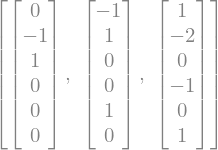

In [5]:
NullDimMat = DimMat.nullspace()
NullDimMat

OK, so what do we do with this information? Well, the entries of these nullspace basis vectors are the powers of $\hat{Q}$, $L$, $h$, $\Delta p$, $V_0$, and $\mu_0$ in a product, as before. Thus, these 3 vectors spanning the nullspace of `DimMat` represent 3 $\Pi$ groups:
$$\Pi_1 = \hat{Q}^{\color{firebrick}{0}}L^{\color{firebrick}{-1}}h^{\color{firebrick}{1}}\Delta p^{\color{firebrick}{0}}V_0^{\color{firebrick}{0}}\mu_0^{\color{firebrick}{0}} = \frac{h}{L},$$
and
$$\Pi_2 = \hat{Q}^{\color{firebrick}{-1}}L^{\color{firebrick}{1}}h^{\color{firebrick}{0}}\Delta p^{\color{firebrick}{0}}V_0^{\color{firebrick}{1}}\mu_0^{\color{firebrick}{0}} = \frac{L V_0}{\hat{Q}},$$
and
$$\Pi_3 = \hat{Q}^{\color{firebrick}{1}}L^{\color{firebrick}{-2}}h^{\color{firebrick}{0}}\Delta p^{\color{firebrick}{-1}}V_0^{\color{firebrick}{0}}\mu_0^{\color{firebrick}{1}} = \frac{\hat{Q}\mu_0}{L^2\Delta p},$$

We don't immediately recognize any of these $\Pi$ groups.

## Non-uniqueness of $\Pi$ groups

Of course, $\Pi$ groups are not unique. New valid $\Pi$ groups can be found as _linear combinations_ of the nullspace basis vectors (from the obvious fact that linear combinations of nullspace vectors are, of course, in the nullspace too). Further, 
*   adding two nullspace basis vectors is the equivalent of multiplying $\Pi$ groups together;
*   multiplying a basis vector by a constant is equivalent to raising that $\Pi$ group to a power.

Consider, for example, $\Pi_1^{2}\Pi_2^{-1}\Pi_3^{-1}$.

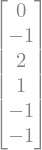

In [6]:
# remember python indexes start at 0
NewPi = 2*NullDimMat[0] - 1*NullDimMat[1] - 1 * NullDimMat[2]  
NewPi

In [7]:
# check that this linear combination is indeed in the nullspace (i.e., dimensionless)
DimMat*NewPi

This new $\Pi$ group above, found as a linear combination the nullspace basis vectors, is
$$
\Pi_1^{2}\Pi_2^{-1}\Pi_3^{-1} = \hat{Q}^{\color{firebrick}{0}}L^{\color{firebrick}{-1}}h^{\color{firebrick}{2}}\Delta p^{\color{firebrick}{1}}V_0^{\color{firebrick}{-1}}\mu_0^{\color{firebrick}{-1}} = \frac{h^2 \Delta p}{\mu_0 V_0 L}.
$$
Indeed, we found this $\Pi$ group in class! It is the Poiseuille number $\mathbb{P}\mathrm{o}$!

## The challenge of finding the "best" combinations

More generally, we always want only 1 $\Pi$ group to involve our original _dependent_ variable, which is the unit vector with a "1" in the first entry.

So, may write a short code to redefine all our nullspace vectors so that only the first one has a "1" in its first entry and the remaining have a "0" there. This will disentangle our $\Pi$ groups a bit.

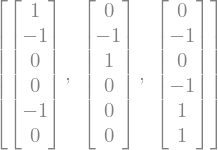

In [8]:
# find the index of the first nullspace vector whose first entry is nonzero.
i = next(k for k, v in enumerate(NullDimMat) if v[0] != 0)

# normalize that entry to 1 and make the rest of the vectors have zero in that entry 
# by subtracting appropriate multiples of the first vector
v0 = NullDimMat[i] / NullDimMat[i][0]
NewNullDimMat = [v0] + [v - v[0]*v0 for k, v in enumerate(NullDimMat) if k != i]

NewNullDimMat

In [9]:
# verify that we didn't screw up and that the new vectors are linearly independent 
# (that is, matrix with each column vectors a row has rank = 3)
sp.Matrix([v.T for k, v in enumerate(NewNullDimMat)]).rank()

Now, these somewhat "improved" 3 vectors, which still span the nullspace of `DimMat`, represent 3 new $\Pi$ groups, let's use checks to denote them:
\begin{align*}
    \check{\Pi}_1 &= \hat{Q}^{\color{firebrick}{1}}L^{\color{firebrick}{-1}}h^{\color{firebrick}{0}}\Delta p^{\color{firebrick}{0}}V_0^{\color{firebrick}{-1}}\mu_0^{\color{firebrick}{0}} = \frac{\hat{Q}}{LV_0},\\
    \check{\Pi}_2 &= \hat{Q}^{\color{firebrick}{0}}L^{\color{firebrick}{-1}}h^{\color{firebrick}{1}}\Delta p^{\color{firebrick}{0}}V_0^{\color{firebrick}{1}}\mu_0^{\color{firebrick}{0}} = \frac{h}{L},\\
    \check{\Pi}_3 &= \hat{Q}^{\color{firebrick}{0}}L^{\color{firebrick}{-1}}h^{\color{firebrick}{0}}\Delta p^{\color{firebrick}{-1}}V_0^{\color{firebrick}{1}}\mu_0^{\color{firebrick}{1}} = \frac{V_0\mu_0}{L\Delta p}.
\end{align*}

These are actually much closer to the ones we sought/expected! Not bad for a 3 lines of python code. 🙂

# FINAL COMMENT: RANK&ndash;NULLITY THEOREM

The dimension of the nullspace of our example `DimMat` is 3, so 3 $\Pi$ groups exist.

This is not a coincidence but a hard mathematical fact! The [_rank&ndash;nullity_ theorem](https://youtu.be/nHlE7EgJFds?t=705) of linear algebra ensures that
$$ \#~\text{columns} - \mathrm{rank}(\text{matrix}) = \mathrm{rank}(\text{nullspace}), $$
or $6-3=3$ indeed!

Recall that the rank of `DimMat` was supposed to be the _minimum_ number of independent dimensions needed to describe all dimensional parameters in the problem. In the traditional approach of picking 'repeating parameters', we took it on faith that `rank(DimMat)=3`, but here we verify this assertion easily:

In [10]:
DimMat.rank()